# Perturbation LOO Evaluation

Evaluates the perturbation model on a held-out cell type in the CRC region.
For each cell type we compute the top-100 pseudobulk logFC genes (CRC vs REF),
perturb REF cells' spatial context accordingly, and measure how well the
predicted expression shift matches the real CRC expression.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
import scvi

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc, load_crc_slide

plt.rcParams['figure.dpi'] = 75
scvi.settings.seed = 0
print(cellina.__version__)

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/en

0.2.0


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 242
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'
top_n_perturb    = 100   # genes used to perturb spatial context
top_n            = 100   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 512
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_{holdout_celltype}'
library_size     = 1e4

## 1. Data Loading

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

## 2. Holdout Split

Mark `holdout_celltype` cells in CRC regions as test (holdout). These cells are used
**only for evaluation** — their ground-truth CRC expression is the target we compare against.

In [4]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  test (holdout): {len(test_idx):,}")
print(f"Holdout cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

train: 375,705  val: 41,744  test (holdout): 3,245
Holdout cells: 3245 T_cell in CRC region


## 3. Spatial Graph & Features

In [5]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)

In [6]:
adata.obsm['spatial'][:,0].min(), adata.obsm['spatial'][:,0].max()

(np.int32(3757), np.int32(109715))

In [7]:
adata.obsm['spatial'][:,1].min(), adata.obsm['spatial'][:,1].max()

(np.int32(12159), np.int32(79040))

## 4. Model Training

In [8]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x',
)

model = CellinaModel(
    adata,
    n_latent=20,
    classifier_lambda=1,
    discriminator_lambda=1,
    condition_on_intrinsic=False,
)

INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [9]:
model.train(
    max_epochs=30,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={
        'lr': 1e-3,
        'weight_decay': 0.0001,
        'normalize_losses': True,
    },
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[1],
)

INFO: GPU available: True (cuda), used: True
2026-03-31 08:48:34 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-03-31 08:48:34 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-03-31 08:48:34 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-03-31 08:48:34 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 597.569. Signaling Trainer to stop.


In [10]:
model.save(save_path, overwrite=True)

## 5. Pseudobulk logFC per Cell Type (CRC vs REF)

In [11]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

cell_types = [
    ct for ct in pdata.obs[labels_key].unique()
    if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
    and ((pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cell_types
    ],
    axis=1,
).T

print(f"logFC matrix: {domain_logfc_df.shape}  (cell types × genes)")
domain_logfc_df.head()

logFC matrix: (8, 3000)  (cell types × genes)


,DDX60L,SH3TC1,RGS7,STAP1,G0S2,PTPRR,ATP13A4,ROS1,MSX2,PSMG4,...,GPR15,ARHGEF4,FAM163A,ACTRT3,RCAN1,PIM1,LAPTM5,APOL1,CXCL5,H3C12
Endothelial,-0.577904,-0.356066,-0.529708,-0.274982,0.112245,-0.754418,-0.121465,-0.359818,-0.625385,-0.023726,...,-0.320390,-0.317067,-0.267649,-0.528553,-0.154368,0.049475,0.689768,-0.026805,-0.527561,0.078071
Epithelial,-0.413618,-0.015889,-0.234075,-0.228569,-0.067379,0.430408,-0.418969,-0.527748,-0.111391,0.041345,...,-0.241690,-0.210079,-0.208957,-0.338790,-0.301606,0.146697,-0.182228,0.670551,-0.441461,0.311994
Fibroblast,-0.453132,-0.337090,-0.372903,-0.400685,-0.452654,-0.387643,-0.275183,-0.488787,-0.477614,-0.471474,...,-0.684369,-0.410710,-0.529076,-0.636689,-0.362732,0.255989,0.433973,0.232396,-0.300495,-0.224854
Mast_cell,-0.266114,0.755196,0.020974,-0.769114,-0.307306,-0.154589,0.081252,-0.778805,-0.554431,-0.162174,...,-0.098884,-0.295956,-0.130437,-0.079095,-0.136951,0.642027,1.396774,0.113619,-0.400048,-0.341742
Myeloid,-0.123918,-0.265512,-0.187573,-0.414656,-0.213312,-0.321049,-0.069781,-0.511003,-0.421269,-0.557012,...,-0.323155,-0.156370,-0.456663,-0.120254,0.016705,0.205870,0.573811,0.080854,0.067158,-0.016721


## 6. Perturbation: Top-100 Genes per Cell Type

In [12]:
logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
    logfc_series_dict[ct] = s[top_genes]

make_neighbor_perturbation(
    adata,
    perturbations=logfc_series_dict,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

## 7. Expression Retrieval & Metrics

In [13]:
rows = []
logfcs = {}

for ct in sorted(cell_types):
    ref_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    crc_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == crc_label)

    # For the holdout cell type, evaluate only on holdout cells
    if ct == holdout_celltype:
        crc_mask = crc_mask & adata.obs['is_holdout']

    ref_idx = np.where(ref_mask.values)[0]
    crc_idx = np.where(crc_mask.values)[0]

    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue

    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")

    # ref_expr  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    ref_expr = sc.pp.normalize_total(adata[ref_idx], target_sum=library_size, inplace=False)['X']
    ref_expr = ref_expr.toarray() if hasattr(adata[ref_idx].X, 'toarray') else ref_expr
    pert_expr = model.get_perturbed_expression(adata=adata, indices=ref_idx, spatial_obsm_key='spatial_x_cf', batch_size=batch_size, library_size=library_size)
    cf_expr   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)

    stats = compute_cf_logfc(
        ref_expr, pert_expr, cf_expr,
        top_n=top_n,
        gene_names=adata.var_names.tolist(),
    )

    rows.append(dict(
        cell_type=ct,
        holdout=(ct == holdout_celltype),
        n_ref=len(ref_idx),
        n_crc=len(crc_idx),
        pearson_r=stats['pearson_r'],
        spearman_r=stats['spearman_r'],
        precision=stats['precision'],
        mixing_index=stats['mixing_index'],
    ))
    logfcs[ct] = stats

summary_df = pd.DataFrame(rows).sort_values('pearson_r', ascending=False).reset_index(drop=True)
summary_df

  Endothelial: ref=982, crc=1642


/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  Epithelial: ref=19472, crc=53313


/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  Fibroblast: ref=6100, crc=22548


...

  Smooth_muscle: ref=1571, crc=1672


/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  T_cell: ref=4580, crc=3245


/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


,cell_type,holdout,n_ref,n_crc,pearson_r,spearman_r,precision,mixing_index
0,Epithelial,False,19472,53313,0.965092,0.939358,0.83,0.939811
1,Myeloid,False,1615,4147,0.955820,0.887345,0.61,0.945511
2,Plasma_cell,False,8887,2958,0.934536,0.885605,0.62,0.636564
3,Mast_cell,False,795,383,0.931540,0.843456,0.70,0.976101
4,Smooth_muscle,False,1571,1672,0.881067,0.854689,0.59,0.964354
5,T_cell,True,4580,3245,0.868252,0.747723,0.70,0.983843
6,Endothelial,False,982,1642,0.864642,0.835968,0.51,0.983707
7,Fibroblast,False,6100,22548,0.811933,0.730213,0.57,0.761677


## 8. Visualization: logFC Scatter Plots

In [14]:
assert adata.obs.loc[adata.obs.index[model.test_indices_], labels_key].unique() == [holdout_celltype]

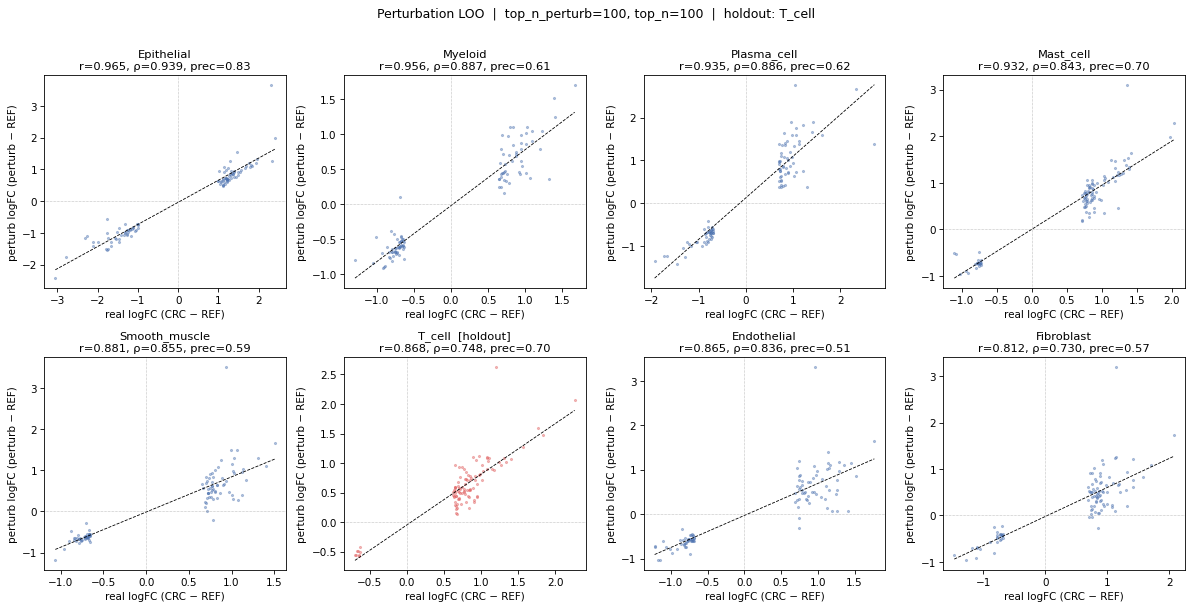

: 

In [ ]:
ncols = 4
nrows = (len(summary_df) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, row in summary_df.iterrows():
    ct  = row['cell_type']
    ax  = axes[i]
    real = logfcs[ct]['real_logfc']
    pred = logfcs[ct]['pred_logfc']
    mask = logfcs[ct]['top_n_mask']
    if mask is not None:
        real, pred = real[mask], pred[mask]

    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(real, pred, s=4, alpha=0.4, color=color)

    m, b = np.polyfit(real, pred, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    title = f"{ct}{'  [holdout]' if row['holdout'] else ''}"
    ax.set_title(
        f"{title}\nr={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=11,
    )
    ax.set_xlabel('real logFC (CRC − REF)', fontsize=10)
    ax.set_ylabel('perturb logFC (perturb − REF)', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Perturbation LOO  |  top_n_perturb={top_n_perturb}, top_n={top_n}  |  holdout: {holdout_celltype}", y=1.01)
plt.tight_layout()
plt.show()